In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier ,HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, confusion_matrix,
                             precision_recall_curve , f1_score , accuracy_score)
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 120)

client = pd.read_csv('Client.csv')
record = pd.read_csv('Record.csv')



In [108]:
client.shape
client.info()
client.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [109]:
record.shape
record.info()
record.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 51 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   rev_Mean         99643 non-null   float64
 1   mou_Mean         99643 non-null   float64
 2   totmrc_Mean      99643 non-null   float64
 3   da_Mean          99643 non-null   float64
 4   ovrmou_Mean      99643 non-null   float64
 5   ovrrev_Mean      99643 non-null   float64
 6   vceovr_Mean      99643 non-null   float64
 7   datovr_Mean      99643 non-null   float64
 8   roam_Mean        99643 non-null   float64
 9   change_mou       99109 non-null   float64
 10  change_rev       99109 non-null   float64
 11  drop_vce_Mean    100000 non-null  float64
 12  drop_dat_Mean    100000 non-null  float64
 13  blck_vce_Mean    100000 non-null  float64
 14  blck_dat_Mean    100000 non-null  float64
 15  unan_vce_Mean    100000 non-null  float64
 16  unan_dat_Mean    100000 non-null  float

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [110]:
print('Duplicate Customer_IDs -> Record:', record['Customer_ID'].duplicated().sum(),'| Client:', client['Customer_ID'].duplicated().sum())

Duplicate Customer_IDs -> Record: 0 | Client: 0


In [111]:
df = record.merge(client, on='Customer_ID', how='inner')
print('Merged shape:', df.shape)
df.head()

Merged shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


Overall churn rate in this dataset: 49.56%


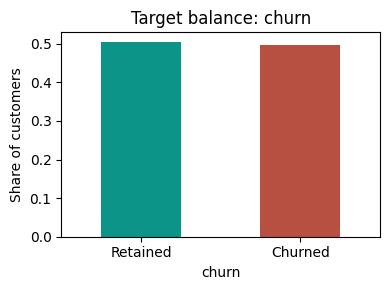

In [112]:
churn_rate = df['churn'].mean()
print(f"Overall churn rate in this dataset: {churn_rate:.2%}")
df['churn'].value_counts(normalize=True).rename({0:'Retained',1:'Churned'}).plot(
    kind='bar', color=['#0D9488','#B85042'], figsize=(4,3), rot=0)
plt.ylabel('Share of customers'); plt.title('Target balance: churn'); plt.tight_layout()

### The above Bar graph shows that dataset has perfectly balanced churn rate

In [113]:
missing_cnt = df.isna().sum()
top_missing = missing_cnt.sort_values(ascending=False).head(20)
top_missing

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


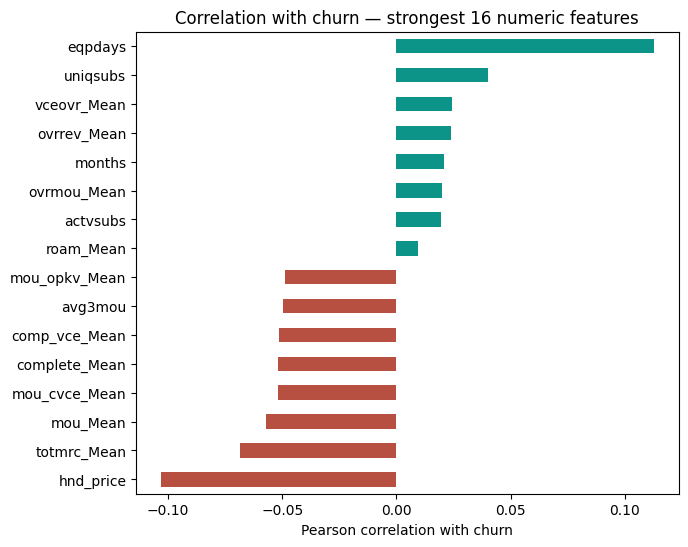

In [114]:
num_cols = df.select_dtypes(include='number').columns.tolist()
churn_corr = df[num_cols].corr()['churn'].drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(7,6))
top = pd.concat([churn_corr.head(8), churn_corr.tail(8)])
colors = ['#B85042' if v < 0 else '#0D9488' for v in top.values]
top.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Correlation with churn — strongest 16 numeric features')
ax.set_xlabel('Pearson correlation with churn')
plt.show()

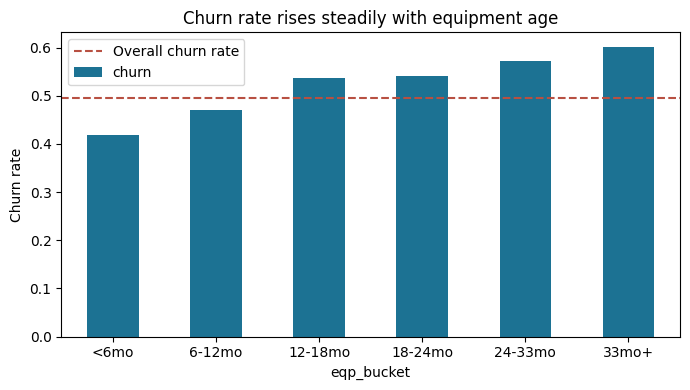

In [115]:
df['eqp_bucket'] = pd.cut(df['eqpdays'], bins=[0,180,365,545,730,1000,3000], labels=['<6mo','6-12mo','12-18mo','18-24mo','24-33mo','33mo+'])
eqp_churn = df.groupby('eqp_bucket', observed=True)['churn'].mean()

fig, ax = plt.subplots(figsize=(7,4))
eqp_churn.plot(kind='bar', color='#1C7293', ax=ax, rot=0)
ax.axhline(df['churn'].mean(), color='#B85042', linestyle='--', label='Overall churn rate')
ax.set_ylabel('Churn rate'); ax.set_title('Churn rate rises steadily with equipment age')
ax.legend(); plt.tight_layout()

Overall average churn rate: 49.56%
                         area  churn_rate_pct  n_customers
NORTHWEST/ROCKY MOUNTAIN AREA       56.908503         4328
           SOUTH FLORIDA AREA       53.361345         3332
        CALIFORNIA NORTH AREA       52.105530         5913
           NORTH FLORIDA AREA       52.000000         4350
             NEW ENGLAND AREA       51.742480         5452
               SOUTHWEST AREA       51.010183         6187
            PHILADELPHIA AREA       50.654129         2446
           NEW YORK CITY AREA       50.027032        11098
             LOS ANGELES AREA       49.819168         6636
                 CHICAGO AREA       49.523439         5141
          ATLANTIC SOUTH AREA       48.972603         6132
                  DALLAS AREA       48.746775         5426
     CENTRAL/SOUTH TEXAS AREA       47.848337         4299
             GREAT LAKES AREA       47.644655         4649
                 HOUSTON AREA       47.500576         4341
               TENNES

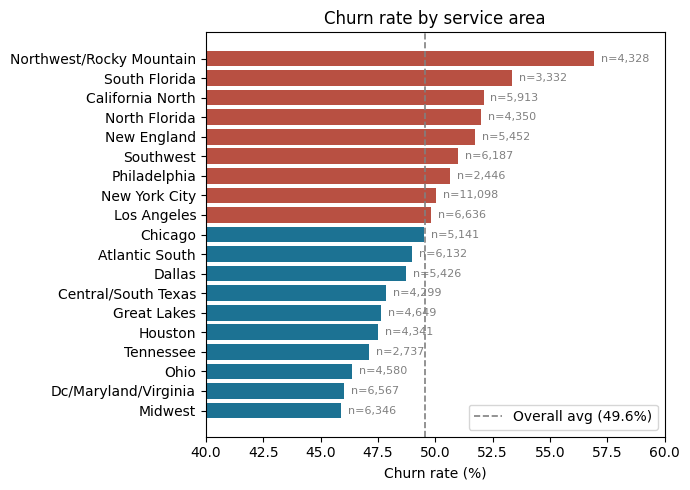

In [116]:
area_stats = (df.groupby('area')['churn'].agg(churn_rate='mean', n_customers='size').reset_index())

area_stats['churn_rate_pct'] = area_stats['churn_rate'] * 100
area_stats = area_stats.sort_values('churn_rate_pct', ascending=False)

overall_avg = df['churn'].mean() * 100
print(f"Overall average churn rate: {overall_avg:.2f}%")
print(area_stats[['area', 'churn_rate_pct', 'n_customers']].to_string(index=False))
X_area = pd.get_dummies(df[['area']].astype('object').fillna('missing'))
for col in X_area.columns:
    mask = X_area[col] == 1
    assert abs(df.loc[mask, 'churn'].mean() * 100 -
               area_stats.loc[area_stats['area'] == col.replace('area_', ''),
                              'churn_rate_pct'].values[0]) < 0.01 \
        if col.replace('area_', '') in area_stats['area'].values else True
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#B85042' if v >= overall_avg else '#1C7293'
          for v in area_stats['churn_rate_pct']]

labels = area_stats['area'].str.replace(' AREA', '', regex=False).str.title()

ax.barh(labels, area_stats['churn_rate_pct'], color=colors)
ax.invert_yaxis()
ax.axvline(overall_avg, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall avg ({overall_avg:.1f}%)')

ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by service area')
ax.set_xlim(40, 60)
ax.legend(loc='lower right')

for i, (rate, n) in enumerate(zip(area_stats['churn_rate_pct'], area_stats['n_customers'])):
    ax.text(rate + 0.3, i, f'n={n:,}', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

### Feature Engineering and Handling the missing values

In [117]:
df['drop_call_ratio']  = df['drop_vce_Mean'] / (df['attempt_Mean'] + 1)
df['complete_ratio']   = df['complete_Mean'] / (df['attempt_Mean'] + 1)
df['revenue_per_min']  = df['rev_Mean'] / (df['mou_Mean'] + 1)
df['custcare_flag']    = (df['custcare_Mean'] > 0).astype(int)
df['eqp_years']        = df['eqpdays'] / 365
df['mou_trend_ratio']  = df['avg3mou'] / (df['avg6mou'] + 1)
df['subs_ratio']       = df['actvsubs'] / (df['uniqsubs'] + 1)
df['mou_ratio']        = df['avgrev'] / (df['avg3mou'] + 1)
df['overage_burden']   = df['ovrrev_Mean'] / (df['rev_Mean'] + 1)


num_features = ['overage_burden','rev_Mean','mou_Mean','totmrc_Mean','ovrmou_Mean','ovrrev_Mean','roam_Mean',
    'change_mou','change_rev','drop_vce_Mean','blck_vce_Mean','unan_vce_Mean','custcare_Mean','eqp_years',
    'threeway_Mean','peak_vce_Mean','opk_vce_Mean','attempt_Mean','numbcars','complete_Mean',
    'drop_call_ratio','complete_ratio','revenue_per_min','custcare_flag',
    'hnd_price','months','totrev','avgrev','avgmou','avg3qty','avg6qty',
    'avg3mou','avg3rev','avg6mou','avg6rev','income','adults','forgntvl','mou_trend_ratio',
              'mou_ratio','uniqsubs','actvsubs','subs_ratio',]

cat_features = ['area','crclscod','asl_flag','new_cell','dualband',
    'refurb_new','hnd_webcap','ownrent','creditcd']

X_num = df[num_features].fillna(df[num_features].median())
X_cat = pd.get_dummies(df[cat_features].astype('object').fillna('missing'), drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = df['churn']

print('Final feature matrix:', X.shape)

Final feature matrix: (100000, 131)


In [118]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=0.5, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=100, max_depth=3, learning_rate=0.15, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=800, max_depth=5, learning_rate=0.03,
              subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
              reg_lambda=1.5, reg_alpha=0.1, random_state=42,
              eval_metric='logloss', n_jobs=-1),
}

result = []
confusion_matrices = {}
probabilities = {}

for name, model in models.items():
    y_proba = cross_val_predict(model, X, y, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    result.append({
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'AUC': roc_auc_score(y, y_proba),
    })
    confusion_matrices[name] = confusion_matrix(y, y_pred)
    probabilities[name] = y_proba

result_df = pd.DataFrame(result).set_index('Model').round(4)
print(result_df)


                     Accuracy      F1     AUC
Model                                        
Logistic Regression    0.5941  0.5846  0.6297
Random Forest          0.6111  0.6223  0.6586
Gradient Boosting      0.6258  0.6289  0.6792
XGBoost                0.6377  0.6374  0.6927


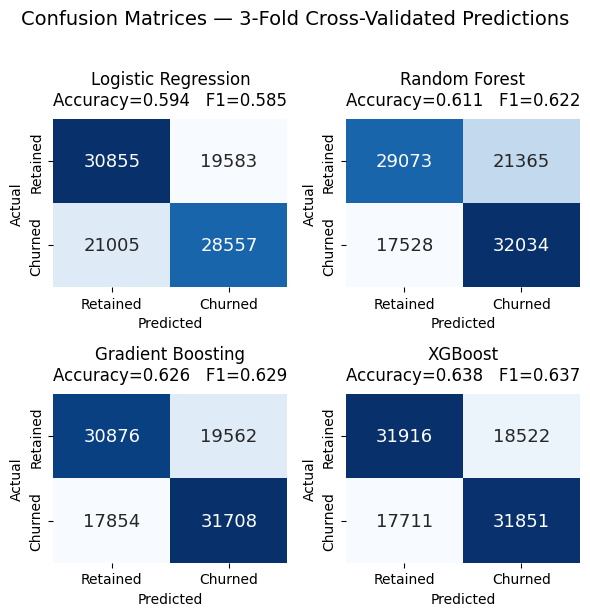

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned'],
        annot_kws={'size': 13}, ax=ax
    )
    acc = result_df.loc[name, 'Accuracy']
    f1  = result_df.loc[name, 'F1']
    ax.set_title(f'{name}\nAccuracy={acc:.3f}   F1={f1:.3f}', fontsize=12, pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — 3-Fold Cross-Validated Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

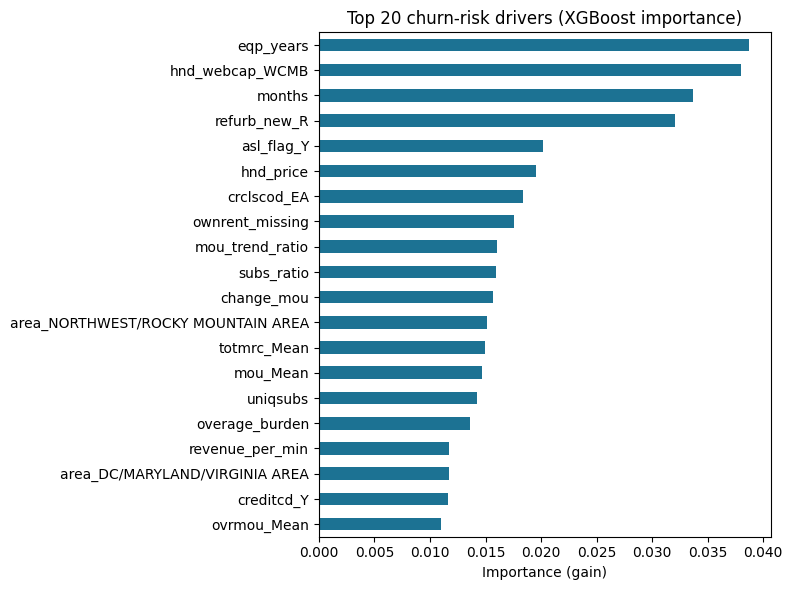

In [120]:
models['XGBoost'].fit(X, y)

importances = pd.Series(models['XGBoost'].feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(20).sort_values().plot(kind='barh', color='#1C7293', ax=ax)
ax.set_title('Top 20 churn-risk drivers (XGBoost importance)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

### Business Simulation - Turning the Score to Retantion Program

In [121]:
# Pick the strongest model automatically (by AUC — the ranking metric the simulation relies on)
best_model_name = result_df['AUC'].idxmax()
best_proba = probabilities[best_model_name]
print(f"Running business simulation using: {best_model_name} (AUC={result_df.loc[best_model_name, 'AUC']:.4f})")

sim = pd.DataFrame({
    'churn_actual': y.values,
    'churn_proba': best_proba,
    'avgrev': df['avgrev'].values
}).sort_values('churn_proba', ascending=False).reset_index(drop=True)

sim['decile'] = pd.qcut(sim.index, 10, labels=False) + 1

decile_summary = sim.groupby('decile').agg(
    customers=('churn_actual', 'size'),
    churn_rate=('churn_actual', 'mean'),
    avg_monthly_revenue=('avgrev', 'mean')
).reset_index()
decile_summary['churn_rate'] = (decile_summary['churn_rate'] * 100).round(1)
decile_summary['avg_monthly_revenue'] = decile_summary['avg_monthly_revenue'].round(2)
print(decile_summary)

Running business simulation using: XGBoost (AUC=0.6927)
   decile  customers  churn_rate  avg_monthly_revenue
0       1      10000        78.5                59.85
1       2      10000        67.0                55.72
2       3      10000        62.3                55.32
3       4      10000        56.1                55.04
4       5      10000        52.7                55.11
5       6      10000        47.9                56.56
6       7      10000        43.0                58.11
7       8      10000        37.7                62.05
8       9      10000        30.8                65.00
9      10      10000        19.8                56.38


Top-decile actual churn rate: 78.5%
Overall churn rate: 49.6%
Lift vs. random targeting: 1.58x
Top-decile avg monthly revenue/customer: $59.85 (vs $57.91 overall)


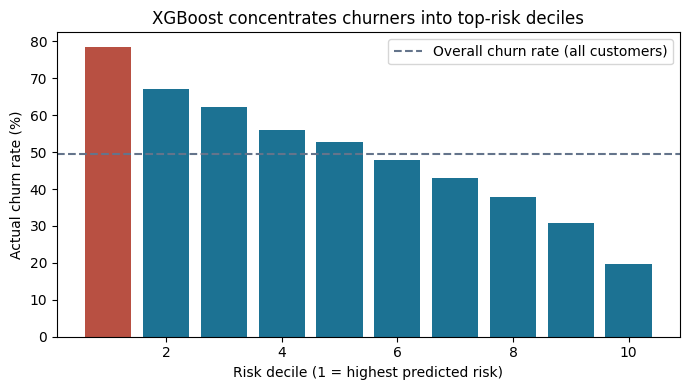

In [122]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(decile_summary['decile'], decile_summary['churn_rate'],
       color=['#B85042' if d == 1 else '#1C7293' for d in decile_summary['decile']])
ax.axhline(y.mean() * 100, color='#64748B', linestyle='--', label='Overall churn rate (all customers)')
ax.set_xlabel('Risk decile (1 = highest predicted risk)'); ax.set_ylabel('Actual churn rate (%)')
ax.set_title(f'{best_model_name} concentrates churners into top-risk deciles')
ax.legend(); plt.tight_layout()

top_decile = sim[sim['decile'] == 1]
lift = top_decile['churn_actual'].mean() / y.mean()
print(f"Top-decile actual churn rate: {top_decile['churn_actual'].mean():.1%}")
print(f"Overall churn rate: {y.mean():.1%}")
print(f"Lift vs. random targeting: {lift:.2f}x")
print(f"Top-decile avg monthly revenue/customer: ${top_decile['avgrev'].mean():.2f} "
      f"(vs ${sim['avgrev'].mean():.2f} overall)")

In [123]:
# Illustrative, assumption-driven business case (see slide deck for narrative + citations)
CUSTOMER_BASE   = 100_000                 # customers scored monthly
TARGET_PCT      = 0.10                    # top decile targeted
TOP_DECILE_CHURN_RATE = top_decile['churn_actual'].mean()
AVG_MONTHLY_REV = top_decile['avgrev'].mean()
SAVE_RATE       = 0.2              # assumed % of *would-be* churners retained by the offer
COST_PER_CONTACT = 50                     # assumed cost of retention outreach/offer per customer

targeted_customers   = CUSTOMER_BASE * TARGET_PCT
expected_churners     = targeted_customers * TOP_DECILE_CHURN_RATE
customers_saved        = expected_churners * SAVE_RATE
annual_revenue_saved   = customers_saved * AVG_MONTHLY_REV * 12
program_cost            = targeted_customers * COST_PER_CONTACT
net_benefit              = annual_revenue_saved - program_cost

print(f"Customers targeted (top decile):      {targeted_customers:,.0f}")
print(f"Expected churners within that group:  {expected_churners:,.0f}")
print(f"Assumed retention success rate:       {SAVE_RATE:.0%}")
print(f"Customers saved from churning:        {customers_saved:,.0f}")
print(f"Estimated annual revenue preserved:   ${annual_revenue_saved:,.0f}")
print(f"Estimated program cost:               ${program_cost:,.0f}")
print(f"Estimated net annual benefit:         ${net_benefit:,.0f}")
print(f"Estimated ROI:                        {net_benefit/program_cost:.1%}")

Customers targeted (top decile):      10,000
Expected churners within that group:  7,853
Assumed retention success rate:       20%
Customers saved from churning:        1,571
Estimated annual revenue preserved:   $1,128,057
Estimated program cost:               $500,000
Estimated net annual benefit:         $628,057
Estimated ROI:                        125.6%
